In [ ]:

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import numpy as np
import os # We'll use this for file paths

# Define the base path to our dataset
base_path = '/content/drive/MyDrive/AI_Physio_Coach/dataset/'

# Specify the file we want to load
# This is one of the "Correct" Vicon recordings we inspected earlier
file_path = os.path.join(base_path, 'vicon', 'G3-Vicon-CTK-P1T1-Unknown-C-0.txt')

# Check if the file exists to avoid errors
if os.path.exists(file_path):
    print(f"File found at: {file_path}")
else:
    print(f"File not found! Please check the path: {file_path}")

File found at: /content/drive/MyDrive/AI_Physio_Coach/dataset/vicon/G3-Vicon-CTK-P1T1-Unknown-C-0.txt


In [ ]:
# Import the numpy library, which is the standard for numerical operations in Python
import numpy as np

# Use numpy's loadtxt function to read the text file into a NumPy array
# This reads all the numbers and organizes them into a 2D grid (matrix)
skeleton_data = np.loadtxt(file_path)

# The .shape attribute is one of the most important properties of a NumPy array.
# It tells us its dimensions in (rows, columns) format.
print(f"The shape of our data is: {skeleton_data.shape}")

The shape of our data is: (390, 119)


In [ ]:
# Reshape the 2D array into a more intuitive 3D array.
# The shape will become (frames, joints, features_per_joint)
structured_data = skeleton_data.reshape(390, 17, 7)

# Print the new shape to confirm our calculation was correct
print(f"The new, structured shape of our data is: {structured_data.shape}")

The new, structured shape of our data is: (390, 17, 7)


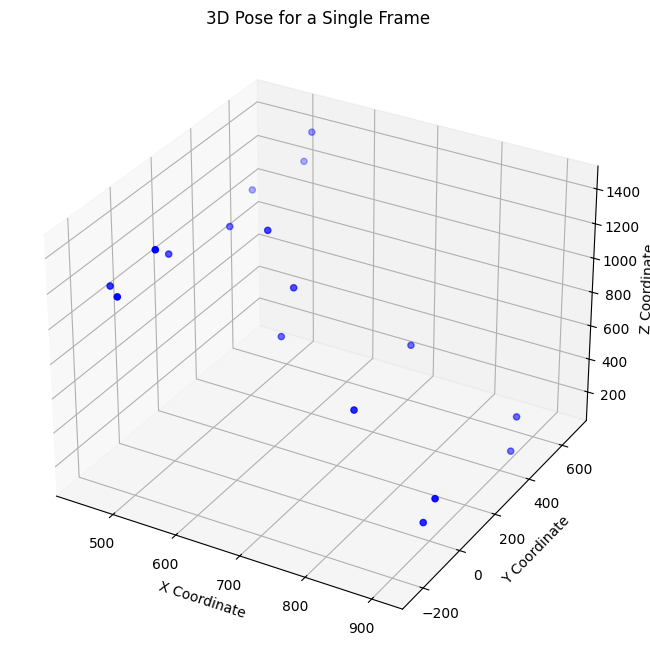

In [ ]:
# Import the necessary plotting libraries
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D # This is needed for 3D plots

# Let's select a single frame to visualize, for example, the middle frame
frame_to_visualize = structured_data[195] # We're picking frame 195 out of 390

# Extract the X, Y, and Z coordinates for all 17 joints
# The ':' means "select all joints"
# 0, 1, 2 are the column indices for X, Y, Z
x_coords = frame_to_visualize[:, 0]
y_coords = frame_to_visualize[:, 1]
z_coords = frame_to_visualize[:, 2]

# Create the 3D plot
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

# Add the joints as a scatter plot
ax.scatter(x_coords, y_coords, z_coords, c='blue', marker='o')

# Label the axes for clarity
ax.set_xlabel('X Coordinate')
ax.set_ylabel('Y Coordinate')
ax.set_zlabel('Z Coordinate')
ax.set_title('3D Pose for a Single Frame')

# Show the plot
plt.show()

In [ ]:
# Import the tools we need for animation and to display it in Colab
from matplotlib import animation
from IPython.display import HTML

# --- Define the Skeleton Connections ---
# We need to tell Matplotlib which joints to connect with lines.
# This is a standard representation for a 17-joint skeleton.
# Each tuple represents a "bone" connecting two joint indices.
skeleton_bones = [
    (0, 1), (1, 2), (2, 3),  # Spine
    (0, 4), (4, 5), (5, 6),  # Left Leg
    (0, 7), (7, 8), (8, 9),  # Right Leg
    (2, 10), (10, 11), (11, 12), # Right Arm
    (2, 13), (13, 14), (14, 15), # Left Arm
    (2, 16) # Neck to head (assuming joint 16 is the head)
]

# --- Set up the plot ---
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

# --- Animation Function ---
# This function will be called for each frame of the animation
def update(frame_number):
    # Clear the previous plot
    ax.clear()

    # Get the skeleton data for the current frame
    current_frame_data = structured_data[frame_number]

    # Extract X, Y, Z coordinates for all joints
    x = current_frame_data[:, 0]
    y = current_frame_data[:, 1]
    z = current_frame_data[:, 2]

    # Plot the joints as points
    ax.scatter(x, y, z, c='blue', marker='o')

    # Plot the bones as lines
    for bone in skeleton_bones:
        start_joint_index = bone[0]
        end_joint_index = bone[1]

        # Get coordinates for the start and end of the bone
        bone_x = [x[start_joint_index], x[end_joint_index]]
        bone_y = [y[start_joint_index], y[end_joint_index]]
        bone_z = [z[start_joint_index], z[end_joint_index]]

        ax.plot(bone_x, bone_y, bone_z, 'r') # 'r' for red lines

    # Set axis limits to keep the view consistent
    ax.set_xlim([0, 1000])
    ax.set_ylim([-500, 500])
    ax.set_zlim([0, 1400])

    # Add labels
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title(f'Physiotherapy Exercise Animation (Frame {frame_number})')

# --- Create and Display the Animation ---
# Create the animation object
# We'll animate the first 390 frames, with a 50ms delay between frames
ani = animation.FuncAnimation(fig, update, frames=len(structured_data), interval=50)

# Convert the animation to HTML for display in Colab
plt.close() # Prevents a static plot from showing before the animation
HTML(ani.to_jshtml())

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# --- Centering the Skeleton ---

# First, make a copy of our original data so we don't overwrite it
normalized_data = structured_data.copy()

# Select the root joint (joint 0, the base of the spine) for each of the 390 frames
root_joint_per_frame = normalized_data[:, 0:1, :]

# Subtract the root joint's position from all joints in every frame
centered_data = normalized_data - root_joint_per_frame

# --- Verification ---
# Let's check the position of joint 0 in the first frame of our NEW centered data.
print("Position of root joint (joint 0) in the first frame AFTER centering:")
print(centered_data[0, 0, :3]) # We only need to see the X, Y, Z coordinates

Position of root joint (joint 0) in the first frame AFTER centering:
[0. 0. 0.]


In [ ]:
# --- Scaling the Skeleton ---

# Our torso is defined by the distance between joint 0 (base of spine) and joint 2 (neck)
# Let's get the position of the neck joint in the first frame of our CENTERED data
neck_joint_position = centered_data[0, 2, :3] # Shape is (3,) for X,Y,Z

# Since the root joint (0) is at (0,0,0), the distance is just the length of this vector.
# We calculate the Euclidean distance (L2 norm)
torso_length = np.linalg.norm(neck_joint_position)

print(f"The original torso length for this skeleton is: {torso_length:.2f} units")

# Now, divide all positional data (X, Y, Z) by this torso length.
# We do NOT scale the rotation data (the last 4 values)
scaled_data = centered_data.copy() # Make a copy to work with
scaled_data[:, :, :3] = scaled_data[:, :, :3] / torso_length

# --- Verification ---
# Let's check the new torso length for the first frame. It should now be 1.0
new_neck_position = scaled_data[0, 2, :3]
new_torso_length = np.linalg.norm(new_neck_position)

print(f"The new, scaled torso length is: {new_torso_length:.2f}")

The original torso length for this skeleton is: 200.16 units
The new, scaled torso length is: 1.00


In [ ]:
def preprocess_skeleton(file_path):
    """
    Loads skeleton data from a file, centers it, and scales it.

    Args:
        file_path (str): The full path to the .txt data file.

    Returns:
        numpy.ndarray: The normalized skeleton data with shape (frames, joints, 7),
                       or None if the file is empty or cannot be processed.
    """
    # 1. Load the data
    try:
        skeleton_data = np.loadtxt(file_path)
        if skeleton_data.size == 0:
            print(f"Warning: File is empty, skipping. {file_path}")
            return None
    except Exception as e:
        print(f"Error loading file {file_path}: {e}")
        return None

    # 2. Reshape the data
    num_frames = skeleton_data.shape[0]
    # We know the Vicon data has 17 joints (119 / 7 = 17)
    structured_data = skeleton_data.reshape(num_frames, 17, 7)

    # 3. Center the skeleton
    root_joint_per_frame = structured_data[:, 0:1, :]
    centered_data = structured_data - root_joint_per_frame

    # 4. Scale the skeleton
    neck_joint_position = centered_data[0, 2, :3]
    torso_length = np.linalg.norm(neck_joint_position)

    if torso_length == 0:
        print(f"Warning: Torso length is zero, skipping normalization. {file_path}")
        return centered_data # Return centered data if scaling is not possible

    scaled_data = centered_data.copy()
    scaled_data[:, :, :3] = scaled_data[:, :, :3] / torso_length

    return scaled_data

# --- Let's test our new function ---
test_file_path = '/content/drive/MyDrive/AI_Physio_Coach/dataset/vicon/G3-Vicon-CTK-P1T1-Unknown-C-0.txt'
processed_data = preprocess_skeleton(test_file_path)

if processed_data is not None:
    print("\nFunction test successful!")
    print(f"The shape of the processed data is: {processed_data.shape}")


Function test successful!
The shape of the processed data is: (390, 17, 7)


In [ ]:
import os
import numpy as np

# Define the path to the Vicon data directory
vicon_path = '/content/drive/MyDrive/AI_Physio_Coach/dataset/vicon/'

# Initialize empty lists to store our processed data and labels
all_sequences = []
all_labels = []

# Get the list of all files in the directory
file_list = os.listdir(vicon_path)
total_files = len(file_list)
print(f"Found {total_files} files in the vicon directory. Starting processing...")

# Loop through each file in the directory
for i, filename in enumerate(file_list):
    # We only want to process the .txt files
    if filename.endswith(".txt"):

        # --- 1. Extract the Label from the filename ---
        # Filename example: G3-Vicon-CTK-P1T1-Unknown-C-0.txt
        # We split the name by '-' and look at the second to last part
        parts = filename.split('-')
        label_part = parts[-2]

        # Assign a numerical label: 0 for Correct, 1 for Error
        if label_part == 'C':
            label = 0  # Correct
        else:
            label = 1  # Error

        # --- 2. Preprocess the Skeleton Data ---
        full_file_path = os.path.join(vicon_path, filename)
        processed_sequence = preprocess_skeleton(full_file_path)

        # --- 3. Store the Results ---
        # Make sure the preprocessing was successful before adding
        if processed_sequence is not None:
            all_sequences.append(processed_sequence)
            all_labels.append(label)

    # Print a progress indicator
    if (i + 1) % 100 == 0:
        print(f".", end="")

print("\n\n--- Processing Complete! ---")
# Convert the labels list to a NumPy array for easier analysis
all_labels = np.array(all_labels)

print(f"Successfully processed {len(all_sequences)} sequences.")
print(f"Shape of the first processed sequence: {all_sequences[0].shape}")
print(f"Total 'Correct' (0) samples: {np.sum(all_labels == 0)}")
print(f"Total 'Error' (1) samples: {np.sum(all_labels == 1)}")

Found 540 files in the vicon directory. Starting processing...
.....

--- Processing Complete! ---
Successfully processed 540 sequences.
Shape of the first processed sequence: (390, 17, 7)
Total 'Correct' (0) samples: 135
Total 'Error' (1) samples: 405


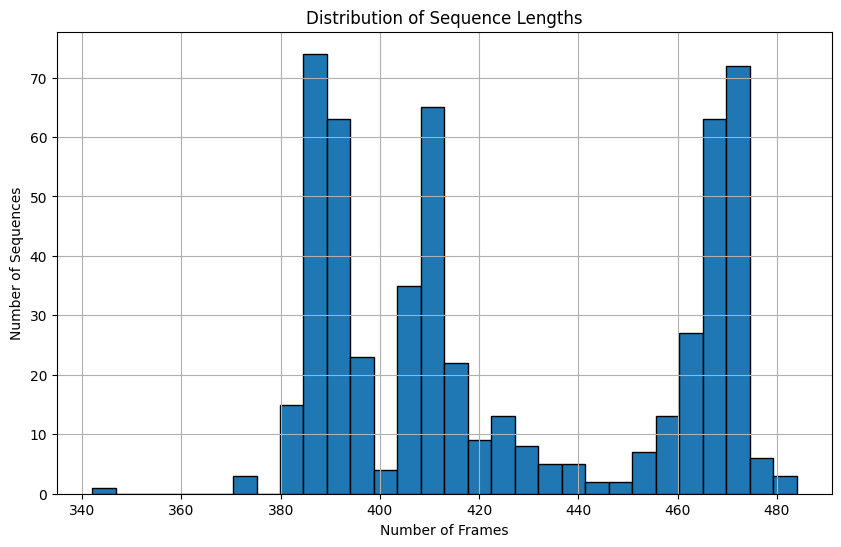

Minimum sequence length: 342
Maximum sequence length: 484
Average sequence length: 425.06


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate the length (number of frames) of each sequence in our list
sequence_lengths = [len(seq) for seq in all_sequences]

# Plot a histogram of the sequence lengths
plt.figure(figsize=(10, 6))
plt.hist(sequence_lengths, bins=30, edgecolor='black')
plt.title('Distribution of Sequence Lengths')
plt.xlabel('Number of Frames')
plt.ylabel('Number of Sequences')
plt.grid(True)
plt.show()

# Print statistics
print(f"Minimum sequence length: {np.min(sequence_lengths)}")
print(f"Maximum sequence length: {np.max(sequence_lengths)}")
print(f"Average sequence length: {np.mean(sequence_lengths):.2f}")

In [ ]:
# We'll use a helpful function from TensorFlow/Keras for padding
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Define our chosen max length
MAX_LENGTH = 500

# The pad_sequences function requires a 3D NumPy array as input,
# but our sequences are in a Python list. Let's convert it first.
# Note: This might show a warning because the sequences have different lengths,
# which is expected and can be ignored.
all_sequences_array = np.array(all_sequences, dtype=object)

# Now, pad all sequences to the MAX_LENGTH
# padding='post' means zeros are added at the end.
# dtype='float32' is an efficient data type for deep learning models.
padded_sequences = pad_sequences(all_sequences_array, maxlen=MAX_LENGTH, padding='post', dtype='float32')

# --- Verification ---
print("Padding complete!")
print(f"The new shape of our entire dataset is: {padded_sequences.shape}")

Padding complete!
The new shape of our entire dataset is: (540, 500, 17, 7)


In [ ]:
# Define the path and filename for our final processed dataset
save_path = '/content/drive/MyDrive/AI_Physio_Coach/vicon_processed_data.npz'

# Use np.savez_compressed to save our arrays efficiently
# We are saving two arrays: 'sequences' and 'labels'
np.savez_compressed(save_path, sequences=padded_sequences, labels=all_labels)

print(f"--- All Done! ---")
print(f"Your final, processed dataset has been saved to: {save_path}")

--- All Done! ---
Your final, processed dataset has been saved to: /content/drive/MyDrive/AI_Physio_Coach/vicon_processed_data.npz
